# Week 2 Module. Protein Structure Prediction with Chai-1
# Part B: Protein Structure Prediction
# Part C: Protein Substrate interaction Prediction
# Part D: Protein Structure PTM and Co-Factor Prediction


This notebook demonstrates how to use Chai-1, a powerful tool for protein structure prediction, including predictions for Post-Translational Modifications (PTMs). You can either use a pre-trained model or fine-tune it with your own data. This notebook will guide you through checking GPU availability, installing necessary packages, preparing input data, running inference, and visualizing the results.

### Before you start — read this, it will save you an hour

**⏩ Do the setup before the exercise slot begins.** You will be told in class when. Two steps, about
ten minutes between them, and they run happily while the lecture carries on:

1. *Runtime → Change runtime type → **T4 GPU***, then *Save*.
2. Run the first two cells — the GPU check and the Chai-1 install.

With that done your 30 minutes go on folding rather than on `pip`. **Leave the tab open**; a closed
Colab session loses everything and the install starts again from scratch.

**1. You need a GPU.** The `!nvidia-smi` cell should print a table with a GPU name in it. If it says
`command not found` or `NVIDIA-SMI has failed`, you are still on CPU and **nothing below will work** —
change the runtime before going any further.

**2. This notebook is mostly waiting.** Realistic timings on a free T4:

| Step | Typical wait | When to run it |
|---|---|---|
| Installing Chai-1 | **~10 min** | **before the exercise slot** |
| First structure prediction (also downloads model weights) | **10–15 min** | during the slot |
| Each later prediction | **5–10 min** | Parts C and D, in your own time |

A prediction prints almost nothing while it runs. **Silence is normal — do not interrupt it.**

**3. Restart the session between parts B, C and D.** Each prediction leaves large tensors in memory,
and without a restart the third will run out of RAM and kill the runtime. *Runtime → Restart
session.* After a restart, `pip` packages survive but **all Python variables are gone**: re-run the
small setup cells for that part (imports, FASTA, output folder), but **not** the 10-minute install.

**4. In the 30-minute slot you should get through Part B**, and that is the intention. Do Part B
properly rather than rushing all three; Parts C and D are written to be done afterwards in your own
time, and the questions at the end of each part are the point, not the pictures.

> **Terms used in this notebook**
>
> **Structure prediction** — computing a protein's 3D coordinates from its sequence. **Chai-1** is a
> model in the AlphaFold-3 family that also handles small molecules, sugars and metal ions.
> **Model 0 … 4** — Chai-1 returns five candidate structures, ranked by its own confidence.
> **pLDDT** — per-residue confidence, 0–100. Above 90: very confident. Below 50: the model does not
> know where this residue is, which usually means the region is disordered. Not a measure of
> correctness — a measure of how sure the model is.
> **pTM** — one number, 0–1, for how confident the model is that the *overall fold* is right.
> **PAE** (predicted aligned error) — for every pair of residues, how wrong the model expects their
> *relative* position to be, in Å. A PAE plot with a low-error block shows a rigid unit; high error
> between two blocks means their relative arrangement is uncertain even if each is well predicted.
> **CIF / PDB** — text formats for 3D coordinates, one line per atom. Predicted structures store
> pLDDT in the column that experimental structures use for the **B-factor**.
> **Ligand** — a small molecule bound to the protein, written as a **SMILES** string (a text encoding
> of its chemistry). **Glycan** — a sugar chain. **Cofactor** — a non-protein helper such as Cu²⁺.
> **Restraint** — an explicit instruction to the model that two atoms are covalently bonded. This is
> how a glycan gets attached to a specific asparagine.

In [1]:
# @title Check GPUs
!nvidia-smi

Sat Sep 12 09:08:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

> **⏳ About 10 minutes — run this before the exercise slot starts.** Chai-1 pulls in PyTorch and a long dependency chain, so expect a lot of
> scrolling output and a long quiet stretch near the end.
>
> `pip` may finish with a red **dependency conflict** warning about NumPy versions. That is expected
> here and usually harmless — if a later cell then fails on an import, use *Runtime → Restart session*
> and carry on from the cell after this one. You do **not** need to install again after a restart.

In [2]:
# @title Install Chai-1. (this will take about 10 min the first time)
!pip install -q chai_lab==0.6.1
# For the bleeding-edge version instead, comment the line above and uncomment below:
# !pip install -q git+https://github.com/chaidiscovery/chai-lab.git

#  In case of dependency conflicts: **Restart the session**

(Chai-1 pulls NumPy v.1.26.4 as part of the dependencies, which can result in conflicts with other packages)

In [3]:
# @title Check that you have chai-lab in /usr/local/bin/
!which chai-lab

/usr/local/bin/chai-lab


## Run inference from command line (**we will not do this here**)
---
Chai-1 ***can*** be run as command-line from a terminal: *chai-lab fold --use-msa-server input.fasta output_folder*

We will not do this. Instead, in this example we will run Chai-1 using python



---


# **B. Structure Prediction**

## Run inference with Python

Protein folding with Chai-1 uses the *chai_lab.chai1.run_inference* function.

In this example the default sequence is a **GH26 mannan endo-1,4-beta-mannosidase from** ***Alistipes dispar***

You can try other seqs if you would like.

The following code produces a list of PDB models and files for analysis:

In [4]:
# @title #### First write FASTA content to input.fasta.
fasta_content = """>protein|BBL06293.1 mannan endo-1,4-beta-mannosidase [Alistipes dispar]
MKRLLLLGLCLLLCPTGYASGKGKRLKAPEKTILKMVDPDATPETKALYANLWCIGLDGVMFGHHDYPSYGIGWKGDKDRSDVKDIVGSHPAVYSLDMAGIDDTKIRHIQEAYKRGGVCMLVWHQSNPLTEGPGKKYPVGTAWDNTKVVDRILQEGSPMNLKYKARLDDVAEAFRKMVDEKGRPIPVIFRPLHEHTQTWNWWGRSATTDREFIAFWRFIVSYLRDTKDVHNVIYAISPQMDAVYDDPVGRILFRWPGDQWVDFIGMDCYHGRNTAAFESNVQAMVEVRGLRHKPVGITETGLENDHKADYWTQDVLRVLRGEPCAMVVAWRNDNPRHAYGPYPSDASAEDFKLFDADEWTLLERDLPDMYSMPKNVTVK
"""

with open("input.fasta", "w") as f:
    f.write(fasta_content)

print(fasta_content)

>protein|BBL06293.1 mannan endo-1,4-beta-mannosidase [Alistipes dispar]
MKRLLLLGLCLLLCPTGYASGKGKRLKAPEKTILKMVDPDATPETKALYANLWCIGLDGVMFGHHDYPSYGIGWKGDKDRSDVKDIVGSHPAVYSLDMAGIDDTKIRHIQEAYKRGGVCMLVWHQSNPLTEGPGKKYPVGTAWDNTKVVDRILQEGSPMNLKYKARLDDVAEAFRKMVDEKGRPIPVIFRPLHEHTQTWNWWGRSATTDREFIAFWRFIVSYLRDTKDVHNVIYAISPQMDAVYDDPVGRILFRWPGDQWVDFIGMDCYHGRNTAAFESNVQAMVEVRGLRHKPVGITETGLENDHKADYWTQDVLRVLRGEPCAMVVAWRNDNPRHAYGPYPSDASAEDFKLFDADEWTLLERDLPDMYSMPKNVTVK



In [5]:
# @title Name Output Directory
output_folder_basename = "output-run001" # @param {type:"string"}

### ⏳ The first prediction takes 10–15 minutes

Longer than the later ones, because this run also downloads the Chai-1 model weights (several GB)
before it can start folding. Later predictions reuse them and take 5–10 minutes.

**You will see very little output while it works.** That is normal. Do not restart the runtime and do
not re-run the cell — you would throw away the download and start over.

A good use of the wait: read the questions at the end of Part B and look up what pLDDT, pTM and PAE
actually measure, so you can answer them from the numbers rather than from the picture.

In [6]:
# @title Run inference with Chai-1 (5-10 min)
# What this cell does: hands input.fasta to Chai-1 and writes five predicted structures plus
# their confidence scores into output_dir. The arguments below:
#   num_trunk_recycles  - how many times the network re-reads its own prediction (more = slower, slightly better)
#   num_diffn_timesteps - steps in the final structure-refinement stage (more = slower, smoother)
#   seed                - fixes the random start so the same input gives the same output
#   device='cuda:0'     - run on the GPU; this is why the notebook needs a GPU runtime
#   use_esm_embeddings  - use a protein language model's view of the sequence as extra input

from pathlib import Path
from chai_lab.chai1 import run_inference

output_dir = Path(f"/content/{output_folder_basename}")
output_dir.mkdir(exist_ok=True)

candidates = run_inference(
    fasta_file=Path("input.fasta"),
    output_dir=output_dir,
    num_trunk_recycles=2,
    num_diffn_timesteps=100,
    seed=42,
    device="cuda:0",
    use_esm_embeddings=True,
)

print("Done. Output files:")
for p in sorted(output_dir.glob("*")):
    print(" ", p)

/usr/local/lib/python3.13/dist-packages/pandera/_pandas_deprecated.py:155: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)
Diffusion steps: 100%|██████████| 99/99 [02:31<00:00,  1.53s/it]


Score=0.1846, writing output to /content/output-run001/pred.model_idx_0.cif
Score=0.1843, writing output to /content/output-run001/pred.model_idx_1.cif
Score=0.1845, writing output to /content/output-run001/pred.model_idx_2.cif
Score=0.1850, writing output to /content/output-run001/pred.model_idx_3.cif
Score=0.1852, writing output to /content/output-run001/pred.model_idx_4.cif
Done. Output files:
  /content/output-run001/pred.model_idx_0.cif
  /content/output-run001/pred.model_idx_1.cif
  /content/output-run001/pred.model_idx_2.cif
  /content/output-run001/pred.model_idx_3.cif
  /content/output-run001/pred.model_idx_4.cif
  /content/output-run001/scores.model_idx_0.npz
  /content/output-run001/scores.model_idx_1.npz
  /content/output-run001/scores.model_idx_2.npz
  /content/output-run001/scores.model_idx_3.npz
  /content/output-run001/scores.model_idx_4.npz


In [7]:
# @title Download 3D models
import shutil
from google.colab import files

# Ensure output_dir is defined. It should be from a previous cell's execution.
# If not, you might need to run the cell that defines `output_dir` (e.g., r5fH3iYn_k0E) first.
# For this context, assuming output_dir is already set to '/content/outputs'.

zip_path = shutil.make_archive(output_folder_basename, "zip", output_dir)
print(f"Downloading {zip_path.split('/')[-1]}...")
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Visualize the models


In [8]:
# @title #Visualize the models in the notebook
!pip install -q py3Dmol
import py3Dmol
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

output_dir = Path(f"/content/{output_folder_basename}")

def display_protein_model(model_idx=0):
    cif_files = sorted(output_dir.glob("pred.model_idx_*.cif"))
    if not cif_files:
        print(f"No CIF files found in {output_dir}. Please ensure `run_inference` has been executed successfully.")
        return

    if model_idx < 0 or model_idx >= len(cif_files):
        print(f"Model index {model_idx} is out of range. Available models are 0 to {len(cif_files)-1}.")
        return

    selected_model_path = cif_files[model_idx]
    print("Showing:", selected_model_path)

    with open(selected_model_path) as f:
        cif_data = f.read()

    view = py3Dmol.view(width=1000, height=800)
    view.addModel(cif_data, "cif")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    # ligands/ions (anything not a standard amino acid) as sticks + spheres
    view.addStyle({"hetflag": True}, {"stick": {"radius": 0.2}, "sphere": {"scale": 0.3}})
    view.zoomTo()
    view.show()

# Create a slider widget for model selection
model_selector = widgets.IntSlider(
    min=0,
    max=4, # Assuming 5 models (0-4)
    step=1,
    description='Select Model:',
    value=0,
    continuous_update=False
)

# Display the interactive widget
display(widgets.interactive(display_protein_model, model_idx=model_selector))

interactive(children=(IntSlider(value=0, continuous_update=False, description='Select Model:', max=4), Output(…

In [9]:
# @title Inspect scores.npz file
import numpy as np
from pathlib import Path

scores = np.load(output_dir / "scores.model_idx_0.npz")
print("Available keys:")
for k in scores.files:
    print(f"  {k}: shape={scores[k].shape}, dtype={scores[k].dtype}")

Available keys:
  aggregate_score: shape=(1,), dtype=float32
  ptm: shape=(1,), dtype=float32
  iptm: shape=(1,), dtype=float32
  per_chain_ptm: shape=(1, 1), dtype=float32
  per_chain_pair_iptm: shape=(1, 1, 1), dtype=float32
  has_inter_chain_clashes: shape=(1,), dtype=bool
  chain_chain_clashes: shape=(1, 1, 1), dtype=int32


In [10]:
# @title
import numpy as np

scores = np.load(output_dir / "scores.model_idx_0.npz")
print("Available keys:")
for k in scores.files:
    print(f"  {k}: shape={scores[k].shape}, dtype={scores[k].dtype}")

Available keys:
  aggregate_score: shape=(1,), dtype=float32
  ptm: shape=(1,), dtype=float32
  iptm: shape=(1,), dtype=float32
  per_chain_ptm: shape=(1, 1), dtype=float32
  per_chain_pair_iptm: shape=(1, 1, 1), dtype=float32
  has_inter_chain_clashes: shape=(1,), dtype=bool
  chain_chain_clashes: shape=(1, 1, 1), dtype=int32


In [11]:
# @title Summarize Model Scores
import pandas as pd
import numpy as np

rows = []
for i in range(5):
    s = np.load(output_dir / f"scores.model_idx_{i}.npz")
    rows.append({
        "model": i,
        "aggregate_score": s["aggregate_score"].item() if "aggregate_score" in s.files else None,
        "ptm": s["ptm"].item() if "ptm" in s.files else None,
        "iptm": s["iptm"].item() if "iptm" in s.files else None,
        "complex_plddt": s["complex_plddt"].item() if "complex_plddt" in s.files else None,
    })

df = pd.DataFrame(rows)
df

,model,aggregate_score,ptm,iptm,complex_plddt
0,0,0.184592,0.922958,0.0,None
1,1,0.184255,0.921275,0.0,None
2,2,0.184471,0.922356,0.0,None
3,3,0.185027,0.925135,0.0,None
4,4,0.185165,0.925826,0.0,None


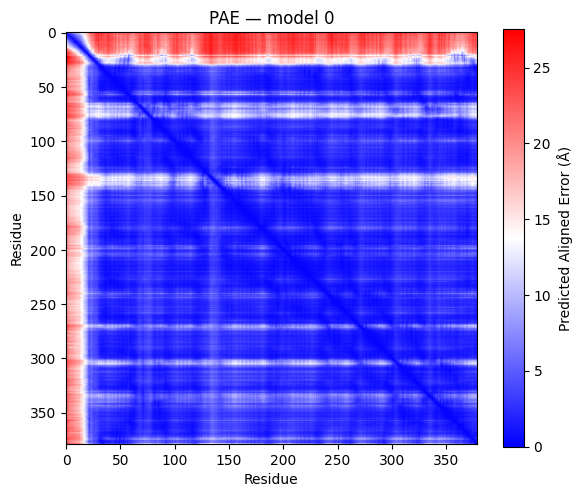

In [12]:
# @title Plot model0
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Access PAE from the candidates object for model 0
pae = candidates.pae[0]

plt.figure(figsize=(6, 5))
plt.imshow(pae, cmap="bwr", vmin=0, vmax=min(30, np.nanmax(pae)))
plt.colorbar(label="Predicted Aligned Error (Å)")
plt.xlabel("Residue")
plt.ylabel("Residue")
plt.title("PAE — model 0")
plt.tight_layout()
plt.savefig(output_dir / "pae_model0.png", dpi=150)
plt.show()

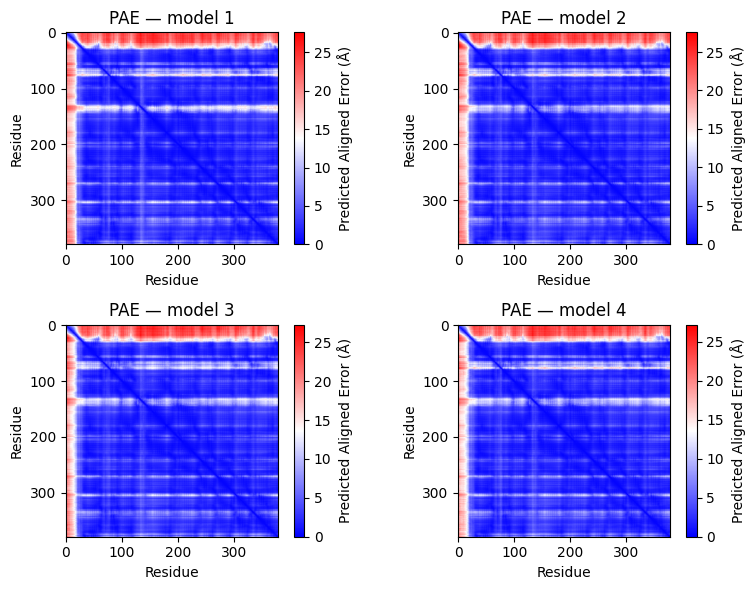

In [13]:
# @title Plot model1-4
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Models to plot
models_to_plot_indices = [1, 2, 3, 4]
num_plots = len(models_to_plot_indices)

# Create a figure with subplots
nrows = 2
ncols = 2 # 2x2 grid for 4 plots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 6)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for plot_idx, model_idx in enumerate(models_to_plot_indices):
    ax = axes[plot_idx]
    # Access PAE from the candidates object for the current model_idx
    if candidates.pae is not None and model_idx < len(candidates.pae):
        pae = candidates.pae[model_idx]
        pae = np.asarray(pae)
        if pae.ndim == 3:
            pae = pae[0] # Take the first PAE matrix if it's 3D (e.g., for multimers)

        im = ax.imshow(pae, cmap="bwr", vmin=0, vmax=min(30, np.nanmax(pae))) # Changed cmap to 'bwr'
        fig.colorbar(im, ax=ax, label="Predicted Aligned Error (Å)")
        ax.set_xlabel("Residue")
        ax.set_ylabel("Residue")
        ax.set_title(f"PAE — model {model_idx}")
    else:
        ax.set_title(f"PAE — model {model_idx} (Not available)")
        ax.text(0.5, 0.5, 'PAE data missing', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(output_dir / "pae_models_1_to_4_panels.png", dpi=150)
plt.show()

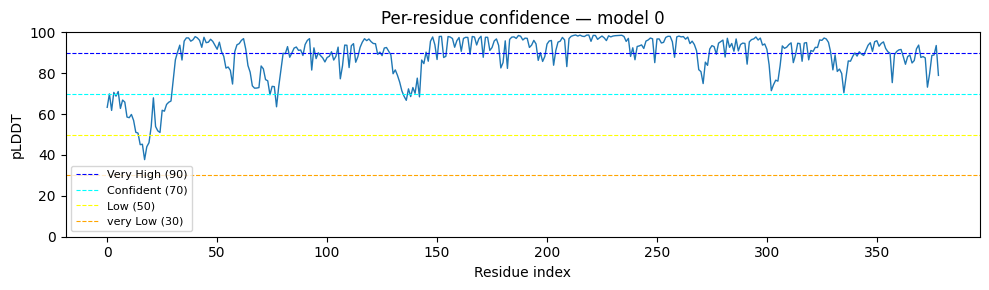

In [14]:
# @title Per-residue confidence (pLDDT) for Model 0
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Access pLDDT from the candidates object for model 0
plddt = candidates.plddt[0]

# normalize to 0-100 scale if it's stored as 0-1
if plddt.max() <= 1.5:
    plddt = plddt * 100

plt.figure(figsize=(10, 3))
plt.plot(plddt, linewidth=1)
plt.axhline(90, color="blue", linestyle="--", linewidth=0.8, label="Very High (90)") # Changed to blue
plt.axhline(70, color="cyan", linestyle="--", linewidth=0.8, label="Confident (70)") # Changed to cyan
plt.axhline(50, color="yellow", linestyle="--", linewidth=0.8, label="Low (50)") # Changed to orange
plt.axhline(30, color="orange", linestyle="--", linewidth=0.8, label="very Low (30)") # Changed to orange
plt.xlabel("Residue index")
plt.ylabel("pLDDT")
plt.ylim(0, 100)
plt.legend(fontsize=8)
plt.title("Per-residue confidence — model 0")
plt.tight_layout()
plt.savefig(output_dir / "plddt_model0.png", dpi=150)
plt.show()

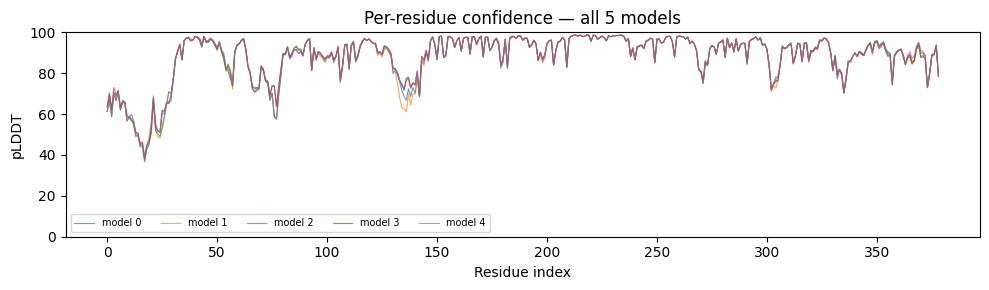

In [15]:
# @title Per-residue confidence (pLDDT) for all 5 models
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

plt.figure(figsize=(10, 3))
for i in range(5):
    # Access pLDDT from the candidates object for model i
    if candidates.plddt is not None and i < len(candidates.plddt):
        p = candidates.plddt[i]
        p = np.asarray(p).squeeze()
        if p.max() <= 1.5:
            p = p * 100
        plt.plot(p, linewidth=0.8, alpha=0.7, label=f"model {i}")
    else:
        print(f"pLDDT for model {i} not found in candidates.") # Debugging line
plt.xlabel("Residue index")
plt.ylabel("pLDDT")
plt.ylim(0, 100)
plt.legend(fontsize=7, ncol=5)
plt.title("Per-residue confidence — all 5 models")
plt.tight_layout()
plt.show()

see what's actually in your output folder

In [16]:
for p in sorted(output_dir.glob("*")):
    print(p.name)

pae_model0.png
pae_models_1_to_4_panels.png
plddt_model0.png
pred.model_idx_0.cif
pred.model_idx_1.cif
pred.model_idx_2.cif
pred.model_idx_3.cif
pred.model_idx_4.cif
scores.model_idx_0.npz
scores.model_idx_1.npz
scores.model_idx_2.npz
scores.model_idx_3.npz
scores.model_idx_4.npz


code to pull pLDDT straight from the CIF B-factor column

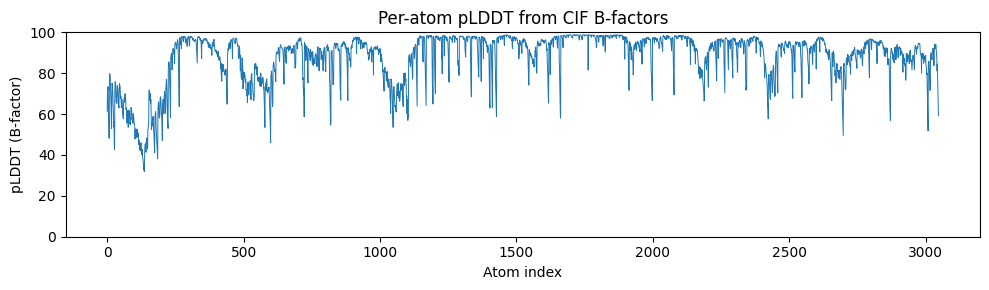

In [17]:
# What this cell does: reads model 0's CIF file atom by atom. Predicted structures store the
# per-residue pLDDT in the B-factor column (which in experimental structures holds atomic
# mobility), so reading that column gives the confidence along the chain.
from Bio.PDB.MMCIFParser import MMCIFParser

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("model0", output_dir / "pred.model_idx_0.cif")

plddt = []
for atom in structure.get_atoms():
    plddt.append(atom.get_bfactor())

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.plot(plddt, linewidth=0.7)
plt.xlabel("Atom index")
plt.ylabel("pLDDT (B-factor)")
plt.ylim(0, 100)
plt.title("Per-atom pLDDT from CIF B-factors")
plt.tight_layout()
plt.show()

# **QUESTIONS**

## 1. What type of protein fold did you get from modelling the GH26 sequence?

**Answer:**
Can check the type of fold in pymol (count beta-strands and alpha-helices)?.



## 2. What do pLDDT, pTM and PAE tell you about the quality of a protein structure prediction?

**Answer:**
pLDDT (predicted local distance difference test) - measures the confidence of each residue.
Score above 90: very high confidence, 70-90: good confidence, 50-70: low confidence, below 50: very low confidence/likely disordered.

A pLDDT plot helps identify well-folded domains (high scores) and flexible loops and termini (lower scores).

From the output image (right above the questions) one can see that the pLDDT varies across the Aa sequence.

pTM assesses confidence in the overall global fold of the protein and reflects whether domains are correctly arranged. PAE indicates the expected positional error between pairs and residues, helping identify regions with uncertain domain orientations or flexible segments.

---


# **C. Predict Enzyme Substrate Interactions**

# ***(To avoid depleting the System RAM -> Restart the Session)***

> ### Restart the session before this part
>
> *Runtime → Restart session.* Part B left large tensors in RAM and Part C will crash without the
> restart.
>
> **After restarting:** Chai-1 is still installed, but every Python variable is gone. Re-run the
> import/FASTA/output-folder cells in this part before the inference cell. Skip the 10-minute install.
>
> **Keep the protein short.** Runtime scales steeply with sequence length, so use one of the ~300 aa
> catalytic domains below. A full-length multi-domain GH26 will run out of memory on a free T4.

## Here we can model GH26 catalytic domains in complex with a carbohydrate substrate.

## Substrates:
1) Mannan : *BMA(4-1 BMA(4-1 BMA(4-1 BMA)))*
2) Glucomannan : *BMA(4-1 BGC(4-1 BMA(4-1 BGC)))*
3) Glucan (cellulose) : *BGC(4-1 BGC(4-1 BGC(4-1 BGC)))*

**(HINT: choose short (<300 aa) GH26 sequences to avoid the runtime from crashing)**


### Examples of GH26 catalytic domains (~300 aa)

>XIK05015.1 glycoside hydrolase family 26 protein [Mesorhizobium sp. AaZ16]
MKNTLITYQSLLPAGAIAALVLSVGALQFTDSFAAPGDPVKFGVYDPDGVFSSRTDVDIEHLFLPWEDVELSTIYEADAYARSRGRVLLVTVEPWTWSPDWRVTPTQLQSRILSGYYDQNMIAICKILNELNSPVTVRWGHEMDDPSGQFTWSRWNPDAYIQAYRRMVDLCRNEAPRVTYMWSPKGEKTMTSYYPGDTYADSIGLSVFGLQKWDNDKFGRDRTFAEILKPGYDRAAAYGKPIVVAELGYVGDTAYVQSWDQAVKQSDPAFPNLTANVYFNQKEVYPWPDGYGLPDWRVTQQVVSN

>ATC26721.1 mannan endo-1,4-beta-mannosidase A and B [Caulobacter vibrioides]
MSNPNASAEARALYTLLWRFYGRKTLTGQQEGVARPDVELDYIEKATGRLPAILGLDYIEPRLNAGVNDRATAWSRSGGIVTICWHWGAPDIGPGYENSKKDFDLTAALQPGTAQNLALHRDLARIGDLLTELRDHKVPVLWRPLHEFSGDWFWWGKHGPAAFKALWALMYDEFTHRRGLDNLIWVAGWAGQNVDPAWHPGRGQVDIAGADIYADDHGALAPMFGAMKAIVGDTIPICLHENGPIPDPALLGPQADWLWFMTWHTRWLMDPGQNDPERLKAFYASDRYLTKDELRSGV

>URZ07408.1 Endoglucanase H [Clostridium felsineum]
MFFKNKFKLVMLSISILIFSLGCFGNGLKVSANRVIKYGAFFADQPTTQGIKDFESLQRKHLDEVNMFINWNTNFSDVKSNFDAVYGDNSTMSLTWEAWGLSNMDIVNGKKDAYIKQMALDMKAYKKNIIIRLFHEGNGNWYDWAVGDSKVNTNETYKAAFRHVVDIFRSVEANNVKWNFNVNCSSVGNGSSYLGQYPGDDYVDTISIDGYNWGTTQSWGSKWQSFDEIFSQPYNALKVKNKPIEISEFSSTEIGGNKAAWYTDAFNQLNSDKYSLINSVVCFSINKETDWRINSSASALRAYIAGIHR

>AGK04542.1 Beta-mannanase [Meiothermus ruber DSM 1279]
MYPGQKDREEYQITPSSLEAYEQAVNRRVAWVYFSNDWFAGRDFPTATAEWIRARNAVPYIRLMLRSSSETYVPEPLYSLQAILRGDFDPDLRAWGRAAQNFGTPLLVEWGTEVNGQWFSWNGRWNGGPTLGPERFREAYRHIVQTIRSVGADNLTWVWHVDAYDDPAAEWNRLENYYPGDDVVDWIGVSVYGAQEPTENNSQTFADGMDAVMPRLLRLAPTKPVVVAEFGVTAGNPGVNAVQWAEAALTDLLANRWPAVRGFSWWNEAFDQTEMRVQVIPGLREVFRSKLDSPKVLDHPL

>AEB13973.1 Mannan endo-1,4-beta-mannosidase [Treponema succinifaciens DSM 2489]
MVQTANKNAIPVAKKLLECLYEISGKKIITGQHTQTVPMEEINFIKSITGKEPKLRGFELLSYSPNINYAESDSECLIEVEENKNTVEQALKWASESSDILTFTFHWFSPLGGKGKSFYSKNTDFDAERILVKGTEERKKFFSDMDSIAEILKKFSNVPILWRPFHESYGDWFWWGAKGPVVAGKLYELMFDYYTNVHKLNNLLWVWNSDVKEAYPGDDKVDVVSIDVYRPEYEPTDYSAEYFKLCEGSSKNKVCALAEVGYIPDVSILEKTHIPWAYYMTWSKEFCIGEKYNTKESLLKMYESPYAVTL


### We can check that if your GH26 sequences has a signal peptide that needs to be removed.

## *https://services.healthtech.dtu.dk/services/SignalP-6.0/*

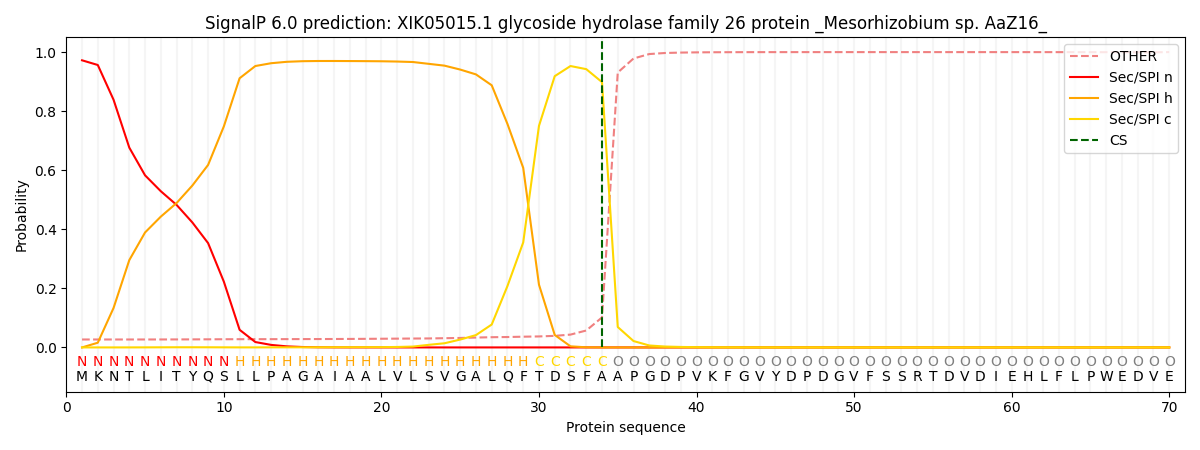

In [1]:
# @title #### We input the processed FASTA sequence and the substrate to input.fasta.
fasta_content = """>protein|XIK05015.1 glycoside hydrolase family 26 protein [Mesorhizobium sp. AaZ16]
APGDPVKFGVYDPDGVFSSRTDVDIEHLFLPWEDVELSTIYEADAYARSRGRVLLVTVEPWTWSPDWRVTPTQLQSRILSGYYDQNMIAICKILNELNSPVTVRWGHEMDDPSGQFTWSRWNPDAYIQAYRRMVDLCRNEAPRVTYMWSPKGEKTMTSYYPGDTYADSIGLSVFGLQKWDNDKFGRDRTFAEILKPGYDRAAAYGKPIVVAELGYVGDTAYVQSWDQAVKQSDPAFPNLTANVYFNQKEVYPWPDGYGLPDWRVTQQVVSN
>glycan|BMA
BMA(4-1 BGC(4-1 BMA(4-1 BGC)))
"""

with open("input.fasta", "w") as f:
    f.write(fasta_content)

print(fasta_content)

>protein|XIK05015.1 glycoside hydrolase family 26 protein [Mesorhizobium sp. AaZ16]
APGDPVKFGVYDPDGVFSSRTDVDIEHLFLPWEDVELSTIYEADAYARSRGRVLLVTVEPWTWSPDWRVTPTQLQSRILSGYYDQNMIAICKILNELNSPVTVRWGHEMDDPSGQFTWSRWNPDAYIQAYRRMVDLCRNEAPRVTYMWSPKGEKTMTSYYPGDTYADSIGLSVFGLQKWDNDKFGRDRTFAEILKPGYDRAAAYGKPIVVAELGYVGDTAYVQSWDQAVKQSDPAFPNLTANVYFNQKEVYPWPDGYGLPDWRVTQQVVSN
>glycan|BMA
BMA(4-1 BGC(4-1 BMA(4-1 BGC)))



In [2]:
# @title Name Output Directory
output_folder_basename = "output-substrate-run008" # @param {type:"string"}

In [3]:
# @title Run inference with Chai-1 (5-10 min)

from pathlib import Path
from chai_lab.chai1 import run_inference

output_dir = Path(f"/content/{output_folder_basename}")
output_dir.mkdir(exist_ok=True)

candidates = run_inference(
    fasta_file=Path("input.fasta"),
    output_dir=output_dir,
    num_trunk_recycles=2,
    num_diffn_timesteps=100,
    num_diffn_samples=2,
    seed=42,
    device="cuda:0",
    use_esm_embeddings=True,
    #use_msa_server=True,
)

print("Done. Output files:")
for p in sorted(output_dir.glob("*")):
    print(" ", p)

/usr/local/lib/python3.13/dist-packages/pandera/_pandas_deprecated.py:155: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)
Diffusion steps: 100%|██████████| 99/99 [01:26<00:00,  1.15it/s]


Score=0.4016, writing output to /content/output-substrate-run008/pred.model_idx_0.cif
Score=0.4558, writing output to /content/output-substrate-run008/pred.model_idx_1.cif
Done. Output files:
  /content/output-substrate-run008/pred.model_idx_0.cif
  /content/output-substrate-run008/pred.model_idx_1.cif
  /content/output-substrate-run008/scores.model_idx_0.npz
  /content/output-substrate-run008/scores.model_idx_1.npz


In [ ]:
# @title Plot model1-4
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Models to plot
models_to_plot_indices = [0, 1]
num_plots = len(models_to_plot_indices)

# Create a figure with subplots
nrows = 1
ncols = 2 # 1x2 grid for 2 plots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5)) # Adjusted figsize for better visual balance
axes = axes.flatten() # Flatten the array of axes for easy iteration

for plot_idx, model_idx in enumerate(models_to_plot_indices):
    ax = axes[plot_idx]
    # Access PAE from the candidates object for the current model_idx
    if candidates.pae is not None and model_idx < len(candidates.pae):
        pae = candidates.pae[model_idx]
        pae = np.asarray(pae)
        if pae.ndim == 3:
            pae = pae[0] # Take the first PAE matrix if it's 3D (e.g., for multimers)

        im = ax.imshow(pae, cmap="bwr", vmin=0, vmax=min(30, np.nanmax(pae))) # Changed cmap to 'bwr'
        fig.colorbar(im, ax=ax, label="Predicted Aligned Error (Å)")
        ax.set_xlabel("Residue")
        ax.set_ylabel("Residue")
        ax.set_title(f"PAE — model {model_idx}")
    else:
        ax.set_title(f"PAE — model {model_idx} (Not available)")
        ax.text(0.5, 0.5, 'PAE data missing', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(output_dir / "pae_models_0_to_1_panels.png", dpi=150)
plt.show()

In [ ]:
# @title Per-residue confidence (pLDDT)
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

def plot_plddt(model_idx=0):
    # Access pLDDT from the candidates object for the selected model_idx
    if candidates.plddt is not None and model_idx < len(candidates.plddt):
        plddt = candidates.plddt[model_idx]
    else:
        print(f"pLDDT data for model {model_idx} not available.")
        return

    # normalize to 0-100 scale if it's stored as 0-1
    plddt = np.asarray(plddt).squeeze()
    if plddt.max() <= 1.5:
        plddt = plddt * 100

    plt.figure(figsize=(10, 3))
    plt.plot(plddt, linewidth=1)
    plt.axhline(90, color="blue", linestyle="--", linewidth=0.8, label="Very High (90)")
    plt.axhline(70, color="cyan", linestyle="--", linewidth=0.8, label="Confident (70)")
    plt.axhline(50, color="yellow", linestyle="--", linewidth=0.8, label="Low (50)")
    plt.axhline(30, color="orange", linestyle="--", linewidth=0.8, label="very Low (30)")
    plt.xlabel("Residue index")
    plt.ylabel("pLDDT")
    plt.ylim(0, 100)
    plt.legend(fontsize=8)
    plt.title(f"Per-residue confidence — model {model_idx}")
    plt.tight_layout()
    plt.savefig(output_dir / f"plddt_model{model_idx}.png", dpi=150)
    plt.show()

# Create a slider widget for model selection
plddt_model_selector = widgets.IntSlider(
    min=0,
    max=len(candidates.plddt) - 1 if candidates.plddt is not None else 0,
    step=1,
    description='Select Model:',
    value=0,
    continuous_update=False
)

# Display the interactive widget
display(widgets.interactive(plot_plddt, model_idx=plddt_model_selector))

In [ ]:
# @title #Visualize the models in the notebook
!pip install -q py3Dmol biopython # Ensure biopython is installed for CIF parsing
import py3Dmol
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display
from Bio.PDB.MMCIFParser import MMCIFParser # Added import for Bio.PDB
from Bio.PDB import NeighborSearch # Import NeighborSearch for distance calculation

output_dir = Path(f"/content/{output_folder_basename}")

def display_protein_model(model_idx=0):
    cif_files = sorted(output_dir.glob("pred.model_idx_*.cif"))
    if not cif_files:
        print(f"No CIF files found in {output_dir}. Please ensure `run_inference` has been executed successfully.")
        return

    if model_idx < 0 or model_idx >= len(cif_files):
        print(f"Model index {model_idx} is out of range. Available models are 0 to {len(cif_files)-1}.")
        return

    selected_model_path = cif_files[model_idx]
    print("Showing:", selected_model_path)

    with open(selected_model_path) as f:
        cif_data = f.read()

    view = py3Dmol.view(width=1000, height=800)
    view.addModel(cif_data, "cif")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    # ligands/ions (anything not a standard amino acid) as sticks + spheres
    view.addStyle({"hetflag": True}, {"stick": {"radius": 0.2}, "sphere": {"scale": 0.3}})

    # Define atom coloring for sticks
    atom_colors = {"C": "grey", "N": "blue", "O": "red"}

    # --- Parse structure for residue-specific highlighting ---
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("model", selected_model_path)
    model = structure[0]

    glycan_atoms = []
    # Highlight NAG, BMA, MAN, and BGC glycans in chain B
    found_glycans = {"NAG": False, "BMA": False, "MAN": False, "BGC": False}
    for chain in model:
        if chain.id == 'B': # Glycans are expected in chain B based on restraints
            for res in chain:
                res_name = res.get_resname()
                if res_name in found_glycans: # Check for specific glycan names
                    view.addStyle({"chain": chain.id, "resi": str(res.get_id()[1])}, {"stick": {"colorscheme": {"prop": "atom", "map": atom_colors}}})
                    print(f"Highlighted {res_name} (Chain {chain.id}, Residue {res.get_id()[1]}) in atom-colored sticks.")
                    found_glycans[res_name] = True
                    # Collect all atoms of the identified glycan
                    for atom in res.get_atoms():
                        glycan_atoms.append(atom)

    for glycan_name, found in found_glycans.items():
        if not found:
            print(f"{glycan_name} glycan not found in Chain B.")

    # --- Highlight Asp/Glu/Tyr residues within 5Å of glycan atoms ---
    if glycan_atoms:
        all_atoms = [atom for atom in model.get_atoms()]
        ns = NeighborSearch(all_atoms)
        highlighted_res = set()

        for glycan_atom in glycan_atoms:
            # Search for atoms within 5Å of the current glycan atom
            # We are interested in atoms belonging to protein residues, specifically Asp, Glu, and Tyr
            close_atoms = ns.search(glycan_atom.get_coord(), 5.0)

            for atom in close_atoms:
                res = atom.get_parent()
                # Check if the residue is from Chain A (protein chain) and is Asp, Glu, or Tyr
                if res.get_parent().id == 'A' and res.get_resname() in ['ASP', 'GLU', 'TYR']:
                    if res not in highlighted_res:
                        view.addStyle({"chain": res.get_parent().id, "resi": str(res.get_id()[1])}, {"stick": {"colorscheme": {"prop": "atom", "map": atom_colors}, "radius":0.3}})
                        print(f"Highlighted {res.get_resname()}{res.get_id()[1]} (Chain {res.get_parent().id}) within 5Å of glycan in atom-colored sticks.")
                        highlighted_res.add(res)
    else:
        print("No glycans found to determine proximity for Asp/Glu/Tyr highlighting.")

    view.zoomTo()
    view.show()

# Create a slider widget for model selection
model_selector = widgets.IntSlider(
    min=0,
    max=1, # Assuming 2 models (0-1)
    step=1,
    description='Select Model:',
    value=0,
    continuous_update=False
)

# Display the interactive widget
display(widgets.interactive(display_protein_model, model_idx=model_selector))

In [ ]:
# @title Download 3D models
import shutil
from google.colab import files

# Ensure output_dir is defined. It should be from a previous cell's execution.
# If not, you might need to run the cell that defines `output_dir` (e.g., r5fH3iYn_k0E) first.
# For this context, assuming output_dir is already set to '/content/outputs'.

zip_path = shutil.make_archive(output_folder_basename, "zip", output_dir)
print(f"Downloading {zip_path.split('/')[-1]}...")
files.download(zip_path)

# **QUESTIONS**

## 1. How would you decide if a predicted enzyme-substrate interaction is reliable, and how would you test it experimentally?

**Answer:**
Check the protein structure quality first (pLDDT should be high, definetly above 70), check the enzyme fold in PyMOL (does it look like you expected?), check conservation of catalytic residues (if they are present in your sequence, positioned correctly), PAE (predicted aligned error) (to know if regions are positioned confidently relative to each other)


Test experimentally: Express and purify the enzyme (cone the GH26 gene, express in a host, often E. coli and purify the protein). Then verify folding and purity using size-exclusion chromatography.

### Questions for Students

1.  **Evaluating Structure Prediction Quality:** How do you know if a predicted protein structure is reliable?
 What do the pLDDT and PAE scores tell you about a predicted protein structure? What does a high pLDDT score for an amino acid mean? What does a low PAE value between two regions of a protein suggest?

**Answer:**
pLDDT: answered earlier in the notebook

PAE (predicted aligned error): extimates the expected positional error between pairs of residues. Low values: high confidence in relative positions, high values: uncertainty in how those regions are positioned relative to each other



2.  **Predicting PTMs and Ligand Interactions:** If you want Chai-1 to predict a protein with a specific modification (such as glycosylation) or with a bound metal ion (such as Cu²⁺), what information would you need to provide in the FASTA file and restraints? What information does Chai-1 use to make these predictions?

**Answer:**
Predicting a glycsylated protein:
- The protein sequence in FASTA file
- Information specifying the modification site
- The identity of the attached glycan
- Restraints defining where the glycan is attached if required by the modelign workflow


Predicting a metal-bound protein (e.g., Cu²⁺):
-The protein sequence.
-The identity of the metal ion (Cu²⁺).
-Information indicating the coordinating residues if known (e.g., His, Cys, Asp, or Glu residues).
-Optional restraints describing the expected metal-binding geometry.


Info Chai-1 uses:
-The primary amino acid sequence.
-Evolutionary information from related protein sequences.
-Structural patterns learned from experimentally solved structures.
-Information about supplied ligands, cofactors, PTMs, and restraints.
-Physical and geometric constraints encoded during model training.


3.  **Experimental Design & Validation:** Imagine you are studying an uncharacterized bacterial enzyme involved in carbohydrate metabolism. You use Chai-1 to predict its structure and potential interactions with a novel substrate. Based on the output plots (PAE, pLDDT, and 3D visualization), how would you determine if your predictions are reliable, and what further experimental steps would you take to validate the predicted substrate binding site?

**Answer:**
See answer earlier in notebook



---


# **D. Predict PTMs and co-factors**

# ***(To avoid depleting the System RAM -> Restart the Session)***

### Here we will use a Lytic Polysaccharide Monooxygenase from *Lentinus similis*.
### The enzymes has Cu(II) co-factor and a glycosylation site (Asn-X-Thr) in Asn33

> ### Restart the session again before this part
>
> Same as before: *Runtime → Restart session*, then re-run only the small setup cells in this part.
>
> **What is different here.** Parts B and C predicted a protein, and a protein with a ligand. This
> part adds two things a sequence alone cannot express: a **Cu(II) cofactor** and an
> **N-glycosylation site**. The glycan is attached through an explicit *restraint file* that names
> the covalent bond — chain, residue, atom.
>
> That is the Week 2 lecture point in a different form. The 20-letter alphabet has no way to say
> "glycosylated at Asn33", so the information has to be supplied to the model out of band. Watch what
> the restraint file has to specify to make it unambiguous.

In [ ]:
# @title Name Output Directory (give a PTM prediction sounding name)
output_folder_basename = "output-ptm-run009" # @param {type:"string"}

### First write FASTA content to input.fasta. This species whch components will me modelled.

In [ ]:
# @title #### Choose glycosylation state
# Glycan definitions
glycosylated_glycan_full_str = "NAG(4-1 NAG(4-1 BMA(3-1 MAN)(6-1 MAN)))"
deglycosylated_glycan_full_str = "NAG"

glycosylation_state = "glycosylated" # @param ["glycosylated", "deglycosylated"]

print(f"Chosen glycosylation state: {glycosylation_state}")

# Print the corresponding glycan string
if glycosylation_state == "glycosylated":
    print(f"Glycan string: {glycosylated_glycan_full_str}")
elif glycosylation_state == "deglycosylated":
    print(f"Glycan string: {deglycosylated_glycan_full_str}")


In [ ]:
# @title #### Write FASTA content to input.fasta

protein_content = """>protein|LYTIC POLYSACCHARIDE MONOOXYGENASE LENTINUS SIMILIS (292560)
HTLVWGVWVNGVDQGDGRNIYIRSPPNNNPVKNLTSPDMTCNVDNRVVPKSVPVNAGDTLTFEWYHNTRDDDIIASSHHGPIAVYIAPAASNGQGNVWVKLFEDAYNVTNSTWAVDRLITAHGQHSVVVPHVAPGDYLFRAEIIALHEADSLYSQNPIRGAQFYISCAQITINSSDDSTPLPAGVPFPGAYTDSTPGIQFNIYTTPATSYVAPPPSVWSGALGGSIAQVGDASLE
"""

ligand_content = """>ligand|CU
[Cu+2]
"""

# Select glycan string based on the chosen glycosylation_state from the previous cell
if glycosylation_state == "glycosylated":
    selected_glycan_str = glycosylated_glycan_full_str
elif glycosylation_state == "deglycosylated":
    selected_glycan_str = deglycosylated_glycan_full_str
else:
    # Default or handle unexpected state, though the @param should prevent this
    selected_glycan_str = ""

# Construct the full FASTA content
fasta_content = protein_content + ">glycan|NAG\n" + selected_glycan_str + "\n" + ligand_content

# Write to file
with open("input.fasta", "w") as f:
    f.write(fasta_content)

# Display the content that was written
print(fasta_content)


## Then we write the Restraints Content to a File.

### This specifies that the N-acetyl glucosamine unit must be covalently linked to Asn33

In [ ]:
# @title #### Write Restraints Content to File.
# What this cell does: writes the one-line instruction that bonds the glycan to the protein.
# Columns: chainA / res_idxA  = the protein chain and residue+atom (N33@N = the side-chain N of Asn33)
#          chainB / res_idxB  = the glycan chain and its atom (@C1 = the first sugar's C1)
#          connection_type    = covalent; min/max distance 0.0 = a true bond, not just proximity
# Without this line Chai-1 would place the glycan near the protein but never attach it.
restraints_content = """chainA,res_idxA,chainB,res_idxB,connection_type,confidence,min_distance_angstrom,max_distance_angstrom,comment,restraint_id
A,N33@N,B,@C1,covalent,1.0,0.0,0.0,protein-glycan,NAG_Asn33
"""

with open("/content/input.restraints", "w") as f:
    f.write(restraints_content)

print("Created /content/input.restraints with content:")
print(restraints_content)

In [ ]:
# @title Run inference with Chai-1

from pathlib import Path
from chai_lab.chai1 import run_inference

output_dir = Path(f"/content/{output_folder_basename}")
output_dir.mkdir(exist_ok=True)

candidates = run_inference(
    fasta_file=Path("input.fasta"),
    output_dir=output_dir,
    constraint_path=Path("/content/input.restraints"), # Added this line
    num_trunk_recycles=2,
    num_diffn_timesteps=100,
    num_diffn_samples=2,
    seed=42,
    device="cuda:0",
    use_esm_embeddings=True,
    #use_msa_server=True,
    #use_templates_server=True,
)

print("Done. Output files:")
for p in sorted(output_dir.glob("*")):
    print(" ", p)

In [ ]:
# @title #Visualize the models in the notebook
!pip install -q py3Dmol biopython # Ensure biopython is installed for CIF parsing
import py3Dmol
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display
from Bio.PDB.MMCIFParser import MMCIFParser # Added import for Bio.PDB

output_dir = Path(f"/content/{output_folder_basename}")

def display_protein_model(model_idx=0):
    cif_files = sorted(output_dir.glob("pred.model_idx_*.cif"))
    if not cif_files:
        print(f"No CIF files found in {output_dir}. Please ensure `run_inference` has been executed successfully.")
        return

    if model_idx < 0 or model_idx >= len(cif_files):
        print(f"Model index {model_idx} is out of range. Available models are 0 to {len(cif_files)-1}.")
        return

    selected_model_path = cif_files[model_idx]
    print("Showing:", selected_model_path)

    with open(selected_model_path) as f:
        cif_data = f.read()

    view = py3Dmol.view(width=1000, height=800)
    view.addModel(cif_data, "cif")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    # ligands/ions (anything not a standard amino acid) as sticks + spheres
    view.addStyle({"hetflag": True}, {"stick": {"radius": 0.2}, "sphere": {"scale": 0.3}})

    # Define atom coloring for sticks
    atom_colors = {"C": "grey", "N": "blue", "O": "red"}

    # --- Parse structure for residue-specific highlighting ---
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("model", selected_model_path)
    model = structure[0]

    # Highlight His1 in chain A
    found_his1 = False
    for chain in model:
        if chain.id == 'A':
            for res in chain:
                # _id[1] is the residue number, get_resname() is the residue type
                if res.get_resname() == 'HIS' and res.get_id()[1] == 1:
                    view.addStyle({"chain": chain.id, "resi": str(res.get_id()[1])}, {"stick": {"colorscheme": {"prop": "atom", "map": atom_colors}}})
                    print(f"Highlighted His1 (Chain {chain.id}, Residue {res.get_id()[1]}) in atom-colored sticks.")
                    found_his1 = True
                    break
        if found_his1:
            break
    if not found_his1:
        print("His1 not found in Chain A.")

    # Highlight His78 in chain A
    found_his78 = False
    for chain in model:
        if chain.id == 'A':
            for res in chain:
                if res.get_resname() == 'HIS' and res.get_id()[1] == 78:
                    view.addStyle({"chain": chain.id, "resi": str(res.get_id()[1])}, {"stick": {"colorscheme": {"prop": "atom", "map": atom_colors}}})
                    print(f"Highlighted His78 (Chain {chain.id}, Residue {res.get_id()[1]}) in atom-colored sticks.")
                    found_his78 = True
                    break
        if found_his78:
            break
    if not found_his78:
        print("His78 not found in Chain A.")

    # Highlight Asn33 in chain A
    found_asn33 = False
    for chain in model:
        if chain.id == 'A':
            for res in chain:
                if res.get_resname() == 'ASN' and res.get_id()[1] == 33:
                    view.addStyle({"chain": chain.id, "resi": str(res.get_id()[1])}, {"stick": {"colorscheme": {"prop": "atom", "map": atom_colors}}})
                    print(f"Highlighted Asn33 (Chain {chain.id}, Residue {res.get_id()[1]}) in atom-colored sticks.")
                    found_asn33 = True
                    break
        if found_asn33:
            break
    if not found_asn33:
        print("Asn33 not found in Chain A.")

    # Highlight Tyr203 in chain A
    found_tyr203 = False
    for chain in model:
        if chain.id == 'A':
            for res in chain:
                if res.get_resname() == 'TYR' and res.get_id()[1] == 203:
                    view.addStyle({"chain": chain.id, "resi": str(res.get_id()[1])}, {"stick": {"colorscheme": {"prop": "atom", "map": atom_colors}}})
                    print(f"Highlighted Tyr203 (Chain {chain.id}, Residue {res.get_id()[1]}) in atom-colored sticks.")
                    found_tyr203 = True
                    break
        if found_tyr203:
            break
    if not found_tyr203:
        print("Tyr203 not found in Chain A.")

    # Highlight NAG, BMA, MAN, and BGC glycans in chain B
    found_glycans = {"NAG": False, "BMA": False, "MAN": False, "BGC": False}
    for chain in model:
        if chain.id == 'B': # Glycans are expected in chain B based on restraints
            for res in chain:
                res_name = res.get_resname()
                if res_name in found_glycans:
                    view.addStyle({"chain": chain.id, "resi": str(res.get_id()[1])}, {"stick": {"colorscheme": {"prop": "atom", "map": atom_colors}}})
                    print(f"Highlighted {res_name} (Chain {chain.id}, Residue {res.get_id()[1]}) in atom-colored sticks.")
                    found_glycans[res_name] = True

    for glycan_name, found in found_glycans.items():
        if not found:
            print(f"{glycan_name} glycan not found in Chain B.")

    view.zoomTo()
    view.show()

# Create a slider widget for model selection
model_selector = widgets.IntSlider(
    min=0,
    max=1, # Assuming 2 models (0-1)
    step=1,
    description='Select Model:',
    value=0,
    continuous_update=False
)

# Display the interactive widget
display(widgets.interactive(display_protein_model, model_idx=model_selector))

In [ ]:
# @title Summarize Model Scores
import pandas as pd
import numpy as np

rows = []
for i in range(2):
    s = np.load(output_dir / f"scores.model_idx_{i}.npz")
    rows.append({
        "model": i,
        "aggregate_score": s["aggregate_score"].item() if "aggregate_score" in s.files else None,
        "ptm": s["ptm"].item() if "ptm" in s.files else None,
        "iptm": s["iptm"].item() if "iptm" in s.files else None,
        "complex_plddt": s["complex_plddt"].item() if "complex_plddt" in s.files else None,
    })

df = pd.DataFrame(rows)
df

In [ ]:
# @title PAE Plots for models 0 and 1
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Models to plot - only models 0 and 1 were generated
models_to_plot_indices = [0, 1]
num_plots = len(models_to_plot_indices)

# Create a figure with subplots for a 1x2 layout
nrows = 1
ncols = 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5)) # Adjust figsize for 1x2 layout
axes = axes.flatten() # Flatten the array of axes for easy iteration

for plot_idx, model_idx in enumerate(models_to_plot_indices):
    ax = axes[plot_idx]
    # Access PAE from the candidates object for the current model_idx
    if candidates.pae is not None and model_idx < len(candidates.pae):
        pae = candidates.pae[model_idx]
        pae = np.asarray(pae)
        if pae.ndim == 3:
            pae = pae[0] # Take the first PAE matrix if it's 3D (e.g., for multimers)

        im = ax.imshow(pae, cmap="bwr", vmin=0, vmax=min(30, np.nanmax(pae))) # Changed cmap to 'bwr'
        fig.colorbar(im, ax=ax, label="Predicted Aligned Error (Å)")
        ax.set_xlabel("Residue")
        ax.set_ylabel("Residue")
        ax.set_title(f"PAE — model {model_idx}")
    else:
        ax.set_title(f"PAE — model {model_idx} (Not available)")
        ax.text(0.5, 0.5, 'PAE data missing', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(output_dir / "pae_models_0_and_1_panels.png", dpi=150)
plt.show()

In [ ]:
# @title Per-residue confidence (pLDDT)
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

def plot_plddt(model_idx=0):
    # Access pLDDT from the candidates object for the selected model_idx
    if candidates.plddt is not None and model_idx < len(candidates.plddt):
        plddt = candidates.plddt[model_idx]
    else:
        print(f"pLDDT data for model {model_idx} not available.")
        return

    # normalize to 0-100 scale if it's stored as 0-1
    plddt = np.asarray(plddt).squeeze()
    if plddt.max() <= 1.5:
        plddt = plddt * 100

    plt.figure(figsize=(10, 3))
    plt.plot(plddt, linewidth=1)
    plt.axhline(90, color="blue", linestyle="--", linewidth=0.8, label="Very High (90)")
    plt.axhline(70, color="cyan", linestyle="--", linewidth=0.8, label="Confident (70)")
    plt.axhline(50, color="yellow", linestyle="--", linewidth=0.8, label="Low (50)")
    plt.axhline(30, color="orange", linestyle="--", linewidth=0.8, label="very Low (30)")
    plt.xlabel("Residue index")
    plt.ylabel("pLDDT")
    plt.ylim(0, 100)
    plt.legend(fontsize=8)
    plt.title(f"Per-residue confidence — model {model_idx}")
    plt.tight_layout()
    plt.savefig(output_dir / f"plddt_model{model_idx}.png", dpi=150)
    plt.show()

# Create a slider widget for model selection
plddt_model_selector = widgets.IntSlider(
    min=0,
    max=len(candidates.plddt) - 1 if candidates.plddt is not None else 0,
    step=1,
    description='Select Model:',
    value=0,
    continuous_update=False
)

# Display the interactive widget
display(widgets.interactive(plot_plddt, model_idx=plddt_model_selector))

In [ ]:
# @title ## Download results
import shutil
from google.colab import files

zip_path = shutil.make_archive(output_folder_basename, "zip", output_dir)
files.download(zip_path)

# **QUESTIONS**

## 1. What inputs are needed for Chai-1 to predict glycosylation or metal-ion binding?

**Answer:**

For Chai-1, the model cannot infer a glycan or metal ion out of thin air. You must provide the relevant chemical entity as part of the input complex.



To model glycosylation, you need:

-The protein sequence.

-The glycan structure itself, supplied as a glycan entity in the input.

-Optionally, restraints or prior information specifying where the glycan is attached if the attachment site is known.

-Chai-1 supports proteins, ligands, nucleic acids, and glycans as input entities.

Examples:

N-linked glycan attached to an Asn residue.
O-linked glycan attached to Ser/Thr.




For a metal-binding prediction you would provide:

-The protein sequence.
-The metal ion as a ligand/entity (e.g., Zn²⁺, Ca²⁺, Mg²⁺, Mn²⁺).
-Optionally MSAs, templates, or experimental restraints to improve confidence.

Chai-1 then co-folds the protein and ligand together and predicts whether the ion occupies a plausible binding site. This is conceptually similar to predicting a protein-small molecule complex.